In [ ]:
# Natural Language Generation using Transformer-based Foundation Models

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")




Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In the world of devils and gods, there is no such thing as a good or bad God. The devil is the devil, and the gods are


In [ ]:
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [17]:
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, TextDataset, DataCollatorForLanguageModeling
import ipywidgets as widgets
import matplotlib.pyplot as plt

In [18]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")

In [19]:
input = tokenizer("In the world of devils and gods", return_tensors="pt")
output = model.generate(**input, max_length=300)
print(tokenizer.decode(output[0]))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In the world of devils and gods, there is no such thing as a good or bad God. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The devil is the devil, and the gods are the gods. The 

In [48]:
import re
import json
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)


def load_text(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return f.read()

def remove_chapter_headings(text):
    text = re.sub(r'Chapter [IVXLCDM]+.*?(?:\n{2,}|\n(?=\w))', '', text, flags=re.IGNORECASE | re.DOTALL)
    text = re.sub(r'IN WHICH.*?(?:\n{2,}|\n(?=\w))', '', text, flags=re.IGNORECASE | re.DOTALL)
    return text

def to_lowercase(text):
    return text.lower()

def remove_special_characters(text):
    return re.sub(r'[^\w\s]', '', text)

def remove_urls(text):
    return re.sub(r'http[s]?://\S+|www\.\S+', '', text)

def remove_digits(text):
    return re.sub(r'\d+', '', text)

def merge_sentences(sentences):
    merged = []
    idx = 0
    while idx < len(sentences):
        current = sentences[idx].strip()
        if len(word_tokenize(current)) < 3:  # Skip fragments
            idx += 1
            continue
        if idx + 1 < len(sentences) and re.match(r'.*\b(Mr\.|Mrs\.|Ms\.|Dr\.|Prof\.|No\.)\s*$', current):
            merged.append(current + ' ' + sentences[idx + 1].strip())
            idx += 2
        else:
            merged.append(current)
            idx += 1
    return merged
text = load_text("story.txt")
def preprocess_text(text):
     text = remove_chapter_headings(text)
     text = to_lowercase(text)
     text = remove_special_characters(text)
     text = remove_urls(text)
     text = remove_digits(text)
     sentences = sent_tokenize(text)
     sentences = merge_sentences(sentences)
     return ' '.join(sentences)
preprocessed_text = preprocess_text(text)
with open('story.txt', 'w', encoding='utf-8') as f:
    f.write(preprocessed_text)

In [51]:
preprocessed_text[:200]

'the one as master the other as man\n\n\nmr phileas fogg lived in  at no  saville row burlington\ngardens the house most noticeable members of the reform club though he seemed always to\navoid attracting at'

In [52]:
train_dataset = TextDataset(
    tokenizer=tokenizer,
    file_path="story.txt",
    block_size=128
)
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False,
)



/usr/local/lib/python3.11/dist-packages/transformers/data/datasets/language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(


In [53]:
print(train_dataset[1].shape)

torch.Size([128])


In [54]:
# 3. Training arguments
training_args = TrainingArguments(
    output_dir="./gpt2-story-large",
    overwrite_output_dir=True,
    num_train_epochs=5,
    per_device_train_batch_size=2,
    save_steps=10_000,
    save_total_limit=2,
    logging_steps=100,
    report_to=[],
)



In [55]:
# 4. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
)



In [56]:
trainer.train()


Step,Training Loss


TrainOutput(global_step=5, training_loss=1.1329216957092285, metrics={'train_runtime': 85.0858, 'train_samples_per_second': 0.118, 'train_steps_per_second': 0.059, 'total_flos': 653230080000.0, 'train_loss': 1.1329216957092285, 'epoch': 5.0})

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Dropdown(description='Prompt:', options=(('Prompt 1', 0), ('Prompt 2', 1), ('Prompt 3', 2)), value=0)

Output()

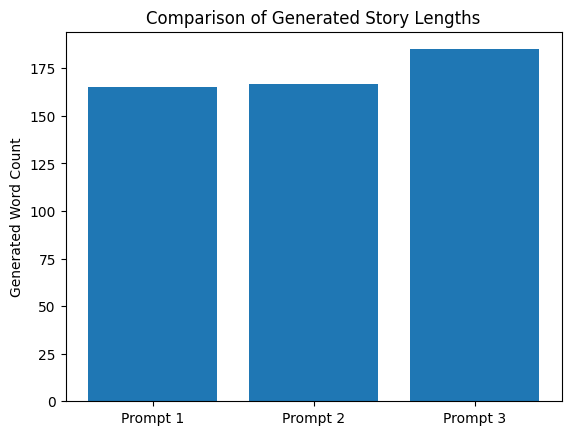

In [57]:
# 6. Define prompts for comparison
prompts = [
    "the one as master the other as man",
    "the mansion in saville row though not sumptuous",
    "I was struck by a thought i stopped and so did heat once"
]

# 7. Generate outputs for each prompt
def generate_text(prompt, max_length=1000):
    inputs = tokenizer.encode(prompt, return_tensors="pt")
    outputs = model.generate(inputs, max_length=max_length, num_return_sequences=1)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

generated_texts = [generate_text(p) for p in prompts]

dropdown = widgets.Dropdown(
    options=[(f"Prompt {i+1}", i) for i in range(len(prompts))],
    description='Prompt:',
)
output = widgets.Output()

def on_change(change):
    with output:
        output.clear_output()
        idx = change['new']
        print(f"Prompt: {prompts[idx]}\n")
        print(generated_texts[idx])

dropdown.observe(on_change, names='value')
display(dropdown, output)
on_change({'new': 0})
lengths = [len(t.split()) for t in generated_texts]
plt.bar(range(len(prompts)), lengths, tick_label=[f"Prompt {i+1}" for i in range(len(prompts))])
plt.ylabel("Generated Word Count")
plt.title("Comparison of Generated Story Lengths")
plt.show()
